# Importing Dataset from Kaggle

In [1]:
import kagglehub

In [2]:
path = kagglehub.dataset_download("zaurbegiev/my-dataset")

In [3]:
print("Path to dataset files:", path)

Path to dataset files: C:\Users\prati\.cache\kagglehub\datasets\zaurbegiev\my-dataset\versions\1


#### We pull our raw dataset using the Kaggle API and load it into a Pandas DataFrame to establish our initial environment.


# Loading Dataset

In [4]:
import pandas as pd

In [5]:
loan_data = pd.read_csv(r"C:\Users\prati\.cache\kagglehub\datasets\zaurbegiev\my-dataset\versions\1\credit_train.csv")

# Inspecting Dataset

In [6]:
loan_data.head(10)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0
5,89d8cb0c-e5c2-4f54-b056-48a645c543dd,4ffe99d3-7f2a-44db-afc1-40943f1f9750,Charged Off,206602.0,Short Term,7290.0,896857.0,10+ years,Home Mortgage,Debt Consolidation,16367.74,17.3,NaN,6.0,0.0,215308.0,272448.0,0.0,0.0
6,273581de-85d8-4332-81a5-19b04ce68666,90a75dde-34d5-419c-90dc-1e58b04b3e35,Fully Paid,217646.0,Short Term,730.0,1184194.0,< 1 year,Home Mortgage,Debt Consolidation,10855.08,19.6,10.0,13.0,1.0,122170.0,272052.0,1.0,0.0
7,db0dc6e1-77ee-4826-acca-772f9039e1c7,018973c9-e316-4956-b363-67e134fb0931,Charged Off,648714.0,Long Term,NaN,NaN,< 1 year,Home Mortgage,Buy House,14806.13,8.2,8.0,15.0,0.0,193306.0,864204.0,0.0,0.0
8,8af915d9-9e91-44a0-b5a2-564a45c12089,af534dea-d27e-4fd6-9de8-efaa52a78ec0,Fully Paid,548746.0,Short Term,678.0,2559110.0,2 years,Rent,Debt Consolidation,18660.28,22.6,33.0,4.0,0.0,437171.0,555038.0,0.0,0.0
9,0b1c4e3d-bd97-45ce-9622-22732fcdc9a0,235c4a43-dadf-483d-aa44-9d6d77ae4583,Fully Paid,215952.0,Short Term,739.0,1454735.0,< 1 year,Rent,Debt Consolidation,39277.75,13.9,NaN,20.0,0.0,669560.0,1021460.0,0.0,0.0


In [7]:
loan_data.shape

(100514, 19)

In [8]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100514 entries, 0 to 100513
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       100000 non-null  object 
 1   Customer ID                   100000 non-null  object 
 2   Loan Status                   100000 non-null  object 
 3   Current Loan Amount           100000 non-null  float64
 4   Term                          100000 non-null  object 
 5   Credit Score                  80846 non-null   float64
 6   Annual Income                 80846 non-null   float64
 7   Years in current job          95778 non-null   object 
 8   Home Ownership                100000 non-null  object 
 9   Purpose                       100000 non-null  object 
 10  Monthly Debt                  100000 non-null  float64
 11  Years of Credit History       100000 non-null  float64
 12  Months since last delinquent  46859 non-null

#### The dataset consists of 100,514 observations and 19 features, including both numerical (float64) and categorical (object) variables, making it suitable for a multi-dimensional classification problem.

# Data Preprocessing

#### Checking for duplicate records as they can affect model training and produce biased results.

In [9]:
loan_data.duplicated().sum()

10728

In [10]:
loan_data = loan_data.drop_duplicates()
loan_data.shape

(89786, 19)

#### Checking for null values.

In [11]:
loan_data.isnull().sum()

Loan ID                             1
Customer ID                         1
Loan Status                         1
Current Loan Amount                 1
Term                                1
Credit Score                    19155
Annual Income                   19155
Years in current job             3803
Home Ownership                      1
Purpose                             1
Monthly Debt                        1
Years of Credit History             1
Months since last delinquent    48338
Number of Open Accounts             1
Number of Credit Problems           1
Current Credit Balance              1
Maximum Open Credit                 3
Bankruptcies                      191
Tax Liens                          10
dtype: int64

#### Rows with missing Loan Status were removed because Loan Status is the target variable. Supervised learning models cannot train on records without a known outcome.

In [12]:
loan_data.dropna(subset=['Loan Status'], inplace=True)

#### Loan ID and Customer ID are unique identifier columns, so they do not help prediction and Months since last delinquent has too many missing values, so removing it.

In [13]:
loan_data.drop(['Loan ID', 'Customer ID', 'Months since last delinquent'], axis=1, inplace=True)

In [14]:
loan_data.isnull().sum()

Loan Status                      0
Current Loan Amount              0
Term                             0
Credit Score                 19154
Annual Income                19154
Years in current job          3802
Home Ownership                   0
Purpose                          0
Monthly Debt                     0
Years of Credit History          0
Number of Open Accounts          0
Number of Credit Problems        0
Current Credit Balance           0
Maximum Open Credit              2
Bankruptcies                   190
Tax Liens                        9
dtype: int64

In [15]:
loan_data['Years in current job'].value_counts()

10+ years    27755
2 years       8254
< 1 year      7365
3 years       7339
5 years       6136
1 year        5832
4 years       5511
6 years       5134
7 years       4989
8 years       4121
9 years       3547
Name: Years in current job, dtype: int64

In [16]:
import numpy as np

In [17]:
def years(value):
    if pd.isnull(value):
        return np.nan
    elif value == '10+ years':
        return 10
    elif value == '< 1 year':
        return 0
    else:
        return int(value.split()[0])

In [18]:
loan_data['Years in current job'] = loan_data['Years in current job'].apply(years)

In [19]:
loan_data['Years in current job'].value_counts().sort_index()

0.0      7365
1.0      5832
2.0      8254
3.0      7339
4.0      5511
5.0      6136
6.0      5134
7.0      4989
8.0      4121
9.0      3547
10.0    27755
Name: Years in current job, dtype: int64

#### Years in current job was originally stored as text, for example "10+ years", "5 years", and "< 1 year". Since employment length has a meaningful order, it was converted into numerical form and treated as an ordinal feature.

In [20]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 89785 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Loan Status                89785 non-null  object 
 1   Current Loan Amount        89785 non-null  float64
 2   Term                       89785 non-null  object 
 3   Credit Score               70631 non-null  float64
 4   Annual Income              70631 non-null  float64
 5   Years in current job       85983 non-null  float64
 6   Home Ownership             89785 non-null  object 
 7   Purpose                    89785 non-null  object 
 8   Monthly Debt               89785 non-null  float64
 9   Years of Credit History    89785 non-null  float64
 10  Number of Open Accounts    89785 non-null  float64
 11  Number of Credit Problems  89785 non-null  float64
 12  Current Credit Balance     89785 non-null  float64
 13  Maximum Open Credit        89783 non-null  flo

In [21]:
numerical_columns = loan_data.select_dtypes(include=['int64', 'float64']).columns
numerical_columns

Index(['Current Loan Amount', 'Credit Score', 'Annual Income',
       'Years in current job', 'Monthly Debt', 'Years of Credit History',
       'Number of Open Accounts', 'Number of Credit Problems',
       'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies',
       'Tax Liens'],
      dtype='object')

In [22]:
categorical_columns = loan_data.select_dtypes(include=['object']).columns
categorical_columns

Index(['Loan Status', 'Term', 'Home Ownership', 'Purpose'], dtype='object')

#### The dataset contains numerical, categorical, and ordinal data.
#### Numerical features include Current Loan Amount, Credit Score, Annual Income, Monthly Debt, Years of Credit History, Number of Open Accounts, Number of Credit Problems, Current Credit Balance, Maximum Open Credit, Bankruptcies, and Tax Liens.
#### Categorical features include Loan Status,Term, Home Ownership, and Purpose.
#### Years in current job is an ordinal feature because it has a meaningful order based on employment duration.

# Exploratory Data Analysis

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

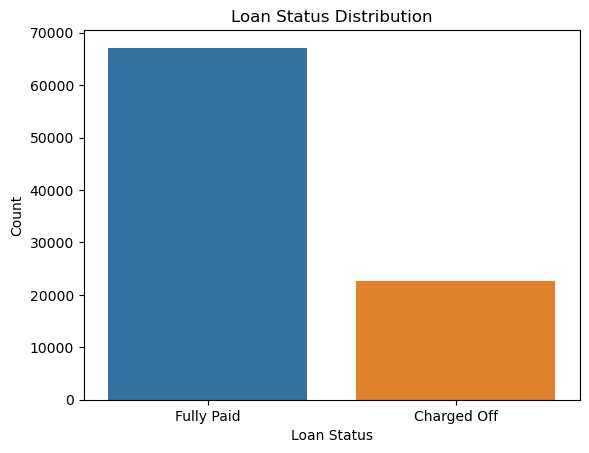

In [24]:
sns.countplot(x='Loan Status', data=loan_data)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.xticks([0, 1], ['Fully Paid', 'Charged Off'])
plt.show()

#### The loan status distribution shows that the dataset contains more Fully Paid loans than Charged Off loans. This means the dataset is imbalanced, which is common in credit risk problems because default cases are usually fewer than successful repayments.

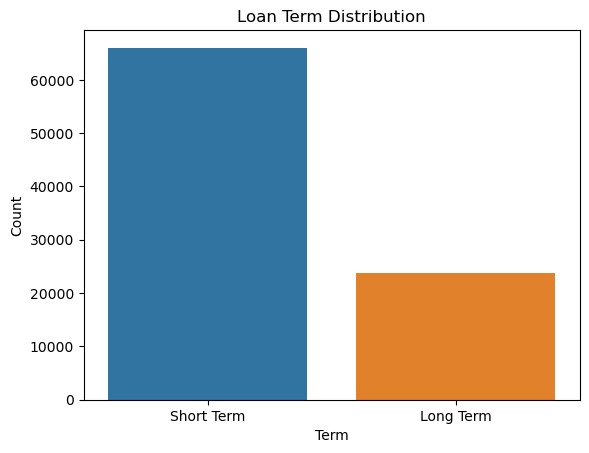

In [25]:
sns.countplot(x='Term', data=loan_data)

plt.title("Loan Term Distribution")
plt.xlabel("Term")
plt.ylabel("Count")

plt.show()

#### The Term column is categorical and shows whether the loan is short term or long term. Loan term may affect repayment risk.¶

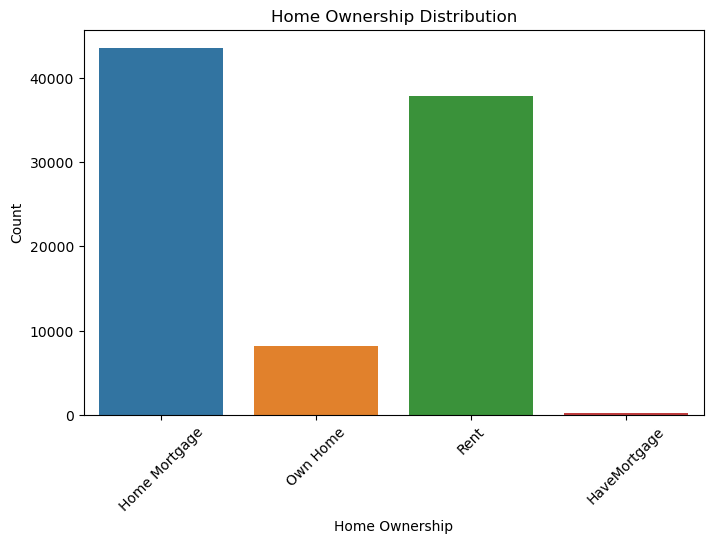

In [26]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Home Ownership', data=loan_data)

plt.title("Home Ownership Distribution")
plt.xlabel("Home Ownership")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

#### Home Ownership is a categorical feature. It may be useful because borrowers with different housing situations may have different financial stability.

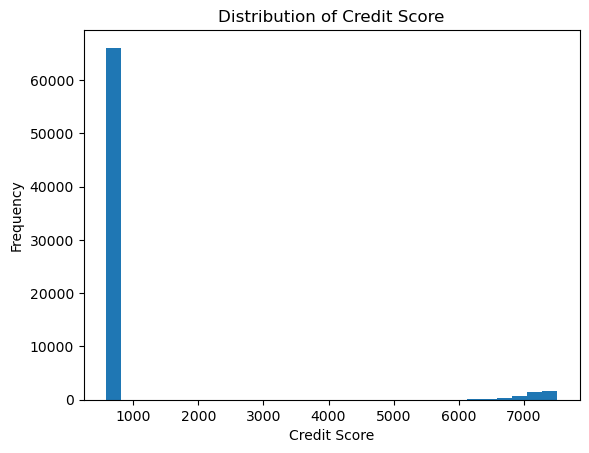

In [27]:
plt.hist(loan_data['Credit Score'], bins=30)

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

#### The histogram for Credit Score shows an anomaly in the data, likely due to outliers, since the standard range for a credit score is generally upto 850.

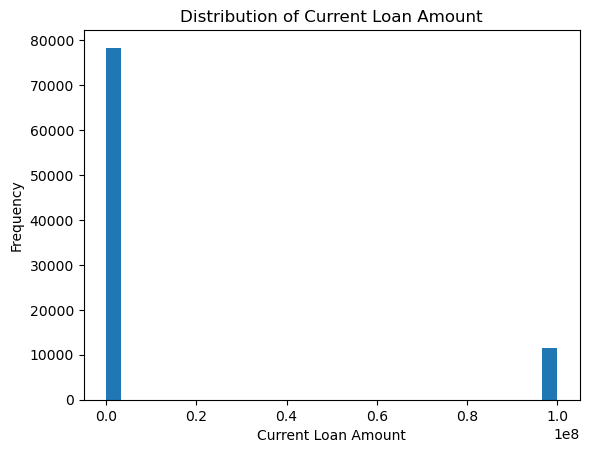

In [28]:
plt.hist(loan_data['Current Loan Amount'], bins=30)

plt.title("Distribution of Current Loan Amount")
plt.xlabel("Current Loan Amount")
plt.ylabel("Frequency")

plt.show()

#### The histogram shows a huge empty gap with an isolated bar on the far right. This bar represents the value 99,999,999, which is an artificial system placeholder, not a real loan amount.

### Detecting and handling outliers

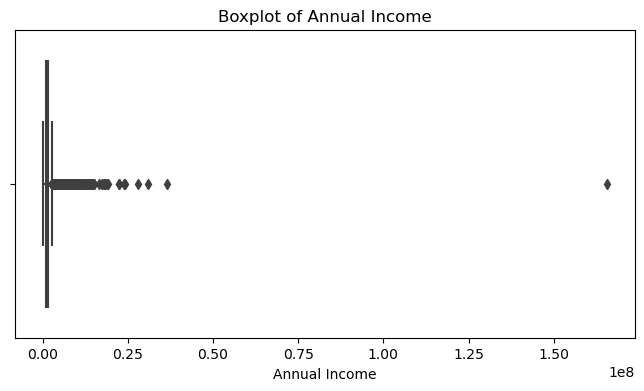

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['Annual Income'])
plt.title("Boxplot of Annual Income")
plt.show()

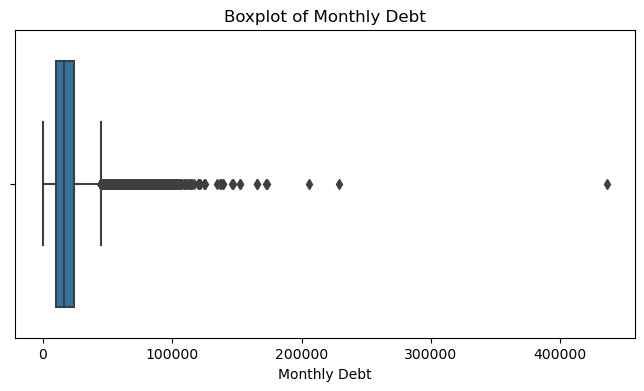

In [30]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['Monthly Debt'])
plt.title("Boxplot of Monthly Debt")
plt.show()

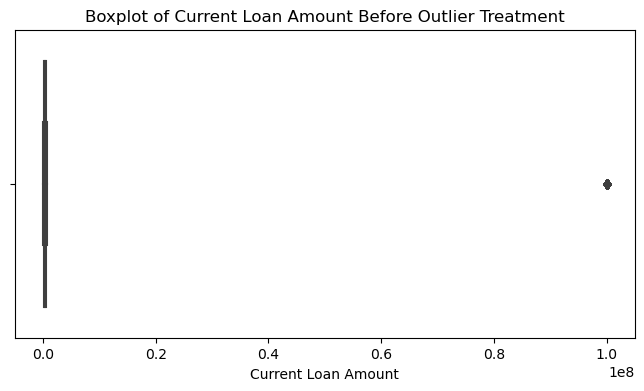

In [31]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['Current Loan Amount'])
plt.title("Boxplot of Current Loan Amount Before Outlier Treatment")
plt.show()

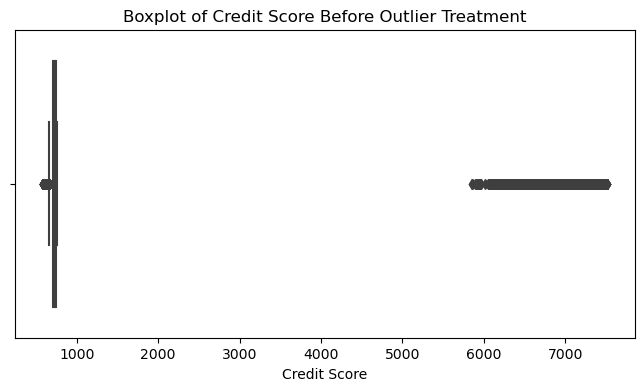

In [32]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['Credit Score'])
plt.title("Boxplot of Credit Score Before Outlier Treatment")
plt.show()

In [33]:
Q1 = loan_data['Current Loan Amount'].quantile(0.25)
Q3 = loan_data['Current Loan Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: -347897.0
Upper limit: 1060543.0


In [34]:
loan_data[(loan_data['Current Loan Amount'] < lower_limit) | 
          (loan_data['Current Loan Amount'] > upper_limit)
].shape

(11484, 16)

In [35]:
Q1 = loan_data['Credit Score'].quantile(0.25)
Q3 = loan_data['Credit Score'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: 657.0
Upper limit: 793.0


In [36]:
loan_data[(loan_data['Credit Score'] < lower_limit) | 
          (loan_data['Credit Score'] > upper_limit)
].shape

(7238, 16)

#### Boxplots and the IQR method were used to detect possible outliers. However, in financial datasets, not every outlier is incorrect. High income, high debt, or high credit balance may represent real borrowers. Therefore, only clearly invalid values will be treated.

In [37]:
loan_data['Current Loan Amount'].describe()

count    8.978500e+04
mean     1.306089e+07
std      3.329556e+07
min      1.080200e+04
25%      1.802680e+05
50%      3.138740e+05
75%      5.323780e+05
max      1.000000e+08
Name: Current Loan Amount, dtype: float64

In [38]:
# pandas in python rounds off large number while summarizing so 1.000000e+08 means 100 million

In [39]:
(loan_data['Current Loan Amount'] == 99999999).sum()

11484

In [40]:
loan_data = loan_data[loan_data['Current Loan Amount'] != 99999999]

In [41]:
loan_data.shape

(78301, 16)

#### The value 99999999 in Current Loan Amount appears unrealistic and may represent a placeholder value. Therefore, rows with this value were removed to reduce the effect of incorrect extreme values.

In [42]:
loan_data['Credit Score'].describe()

count    59147.000000
mean      1209.480971
std       1705.643486
min        585.000000
25%        707.000000
50%        727.000000
75%        742.000000
max       7510.000000
Name: Credit Score, dtype: float64

In [43]:
(loan_data['Credit Score'] > 850).sum()

4551

In [44]:
loan_data.loc[loan_data['Credit Score'] > 850, 'Credit Score'] = loan_data.loc[loan_data['Credit Score'] > 850, 'Credit Score'] / 10

In [45]:
loan_data['Credit Score'].describe()

count    59147.000000
mean       717.187042
std         28.524811
min        585.000000
25%        704.000000
50%        724.000000
75%        739.000000
max        751.000000
Name: Credit Score, dtype: float64

#### Some Credit Score values were greater than the normal credit score range. These values appeared to contain an extra zero, so values greater than 850 were divided by 10 to make them more realistic.

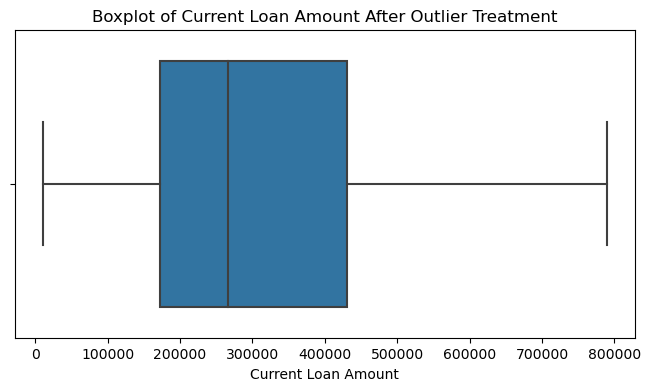

In [46]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['Current Loan Amount'])
plt.title("Boxplot of Current Loan Amount After Outlier Treatment")
plt.show()

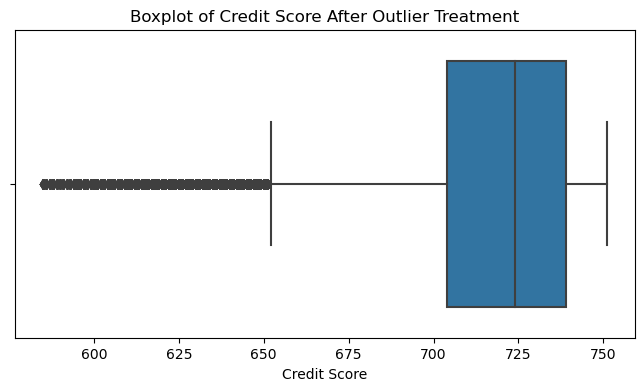

In [47]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=loan_data['Credit Score'])
plt.title("Boxplot of Credit Score After Outlier Treatment")
plt.show()

# Handling Missing values

In [48]:
for column in numerical_columns:
    loan_data[column] = loan_data[column].fillna(loan_data[column].median())

#### Missing numerical values were filled using the median because median is less affected by extreme values.

In [49]:
for column in categorical_columns:
    loan_data[column] = loan_data[column].fillna(loan_data[column].mode()[0])

#### Missing categorical values were filled using the mode because it represents the most frequent category.

In [50]:
loan_data.isnull().sum()

Loan Status                  0
Current Loan Amount          0
Term                         0
Credit Score                 0
Annual Income                0
Years in current job         0
Home Ownership               0
Purpose                      0
Monthly Debt                 0
Years of Credit History      0
Number of Open Accounts      0
Number of Credit Problems    0
Current Credit Balance       0
Maximum Open Credit          0
Bankruptcies                 0
Tax Liens                    0
dtype: int64

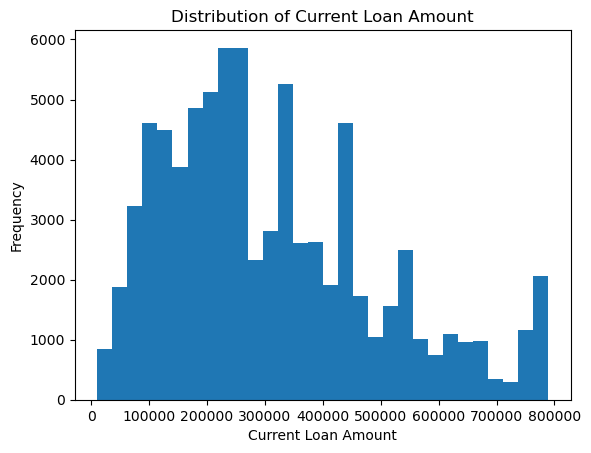

In [51]:
plt.hist(loan_data['Current Loan Amount'], bins=30)

plt.title("Distribution of Current Loan Amount")
plt.xlabel("Current Loan Amount")
plt.ylabel("Frequency")

plt.show()

#### The loan amount distribution shows the range of loan amounts after removing unrealistic placeholder values.

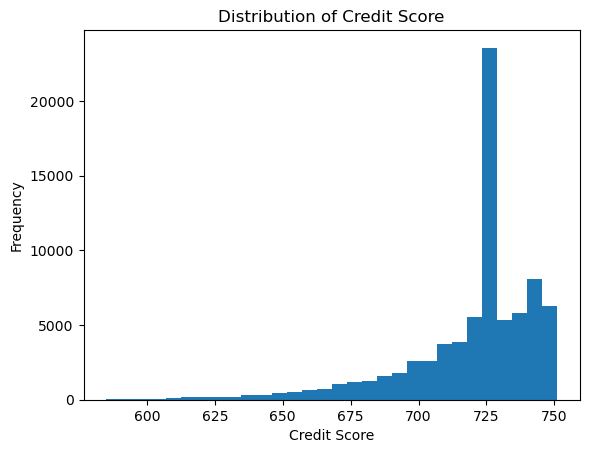

In [52]:
plt.hist(loan_data['Credit Score'], bins=30)

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

#### The credit score distribution after outlier treatment. It shows the spread of borrower credit scores. Credit score is important in credit risk management because it reflects borrower creditworthiness.

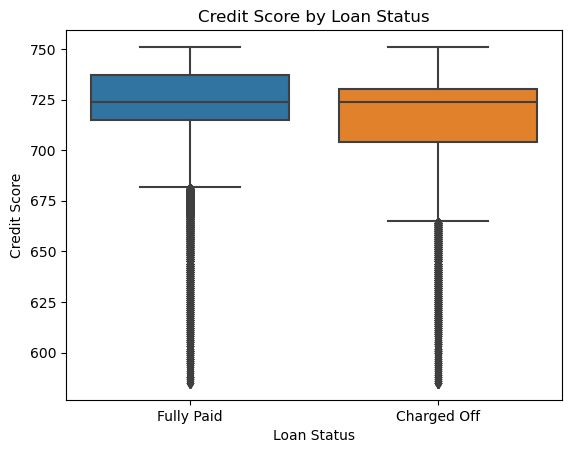

In [53]:
sns.boxplot(x='Loan Status', y='Credit Score', data=loan_data)
plt.title("Credit Score by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Credit Score")
plt.xticks([0, 1], ['Fully Paid', 'Charged Off'])
plt.show()

#### The boxes overlap heavily, but the "Charged Off" median sits lower than the "Fully Paid" median. This proves that while credit scores are highly influential, they overlap too much to be used as a single linear predictor, justifying the need for multi-dimensional ML models.

### Correlation Heatmap

In [54]:
loan_data['Loan Status'].value_counts()

Fully Paid     55662
Charged Off    22639
Name: Loan Status, dtype: int64

In [55]:
loan_data['Loan Status'] = loan_data['Loan Status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

In [56]:
loan_data['Loan Status'].value_counts()

0    55662
1    22639
Name: Loan Status, dtype: int64

#### Loan Status is our target variable. So we have converted it into binary form where 0 represents Fully Paid and 1 represents Charged Off. Charged Off is treated as the risky/default class.

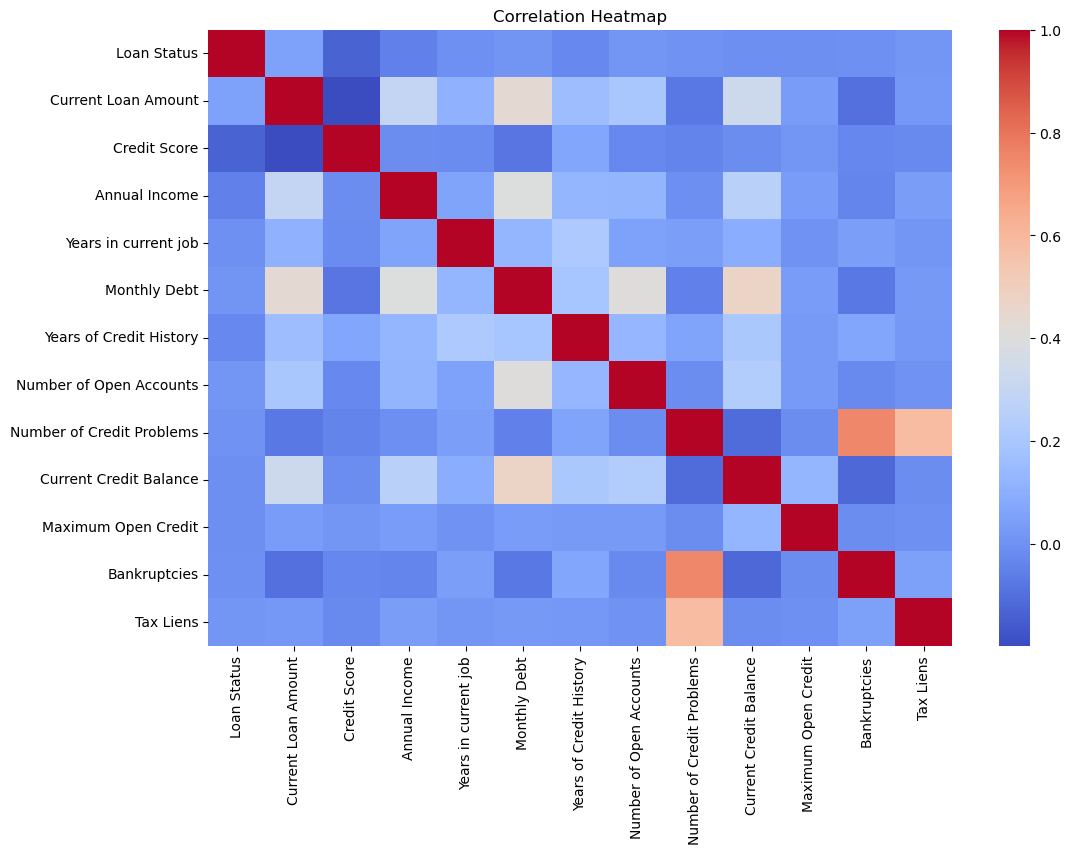

In [57]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    loan_data.select_dtypes(include=['float64', 'int64']).corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

#### The heatmap reveals a strong positive correlation between `Bankruptcies` and `Number of Credit Problems`. We drop `Bankruptcies` because it passes a duplicate risk signal, and removing it simplifies SVM geometry while speeding up training time.

In [58]:
loan_data = loan_data.drop('Bankruptcies', axis=1)

# Data Encoding

In [59]:
categorical_columns = loan_data.select_dtypes(include=['object']).columns
categorical_columns

Index(['Term', 'Home Ownership', 'Purpose'], dtype='object')

In [60]:
loan_data_encoded = pd.get_dummies(loan_data, drop_first=True)

In [61]:
loan_data_encoded.head()

,Loan Status,Current Loan Amount,Credit Score,Annual Income,Years in current job,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,...,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip,Purpose_major_purchase,Purpose_moving,Purpose_other,Purpose_renewable_energy,Purpose_small_business,Purpose_vacation,Purpose_wedding
0,0,445412.0,709.0,1167493.0,8.0,5214.74,17.2,6.0,1.0,228190.0,...,0,0,0,0,0,0,0,0,0,0
1,0,262328.0,724.0,1165536.0,10.0,33295.98,21.1,35.0,0.0,229976.0,...,0,0,0,0,0,0,0,0,0,0
3,0,347666.0,721.0,806949.0,3.0,8741.90,12.0,9.0,0.0,256329.0,...,0,0,0,0,0,0,0,0,0,0
4,0,176220.0,724.0,1165536.0,5.0,20639.70,6.1,15.0,0.0,253460.0,...,0,0,0,0,0,0,0,0,0,0
5,1,206602.0,729.0,896857.0,10.0,16367.74,17.3,6.0,0.0,215308.0,...,0,0,0,0,0,0,0,0,0,0


#### Categorical variables were converted into numerical form using one-hot encoding. This is required because machine learning models cannot directly process text categories.
#### The parameter drop_first=True was used to avoid duplicate category information.

# Creating X and Y

In [62]:
X = loan_data_encoded.drop('Loan Status', axis=1)
Y = loan_data_encoded['Loan Status']

In [63]:
X.head()

,Current Loan Amount,Credit Score,Annual Income,Years in current job,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,...,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip,Purpose_major_purchase,Purpose_moving,Purpose_other,Purpose_renewable_energy,Purpose_small_business,Purpose_vacation,Purpose_wedding
0,445412.0,709.0,1167493.0,8.0,5214.74,17.2,6.0,1.0,228190.0,416746.0,...,0,0,0,0,0,0,0,0,0,0
1,262328.0,724.0,1165536.0,10.0,33295.98,21.1,35.0,0.0,229976.0,850784.0,...,0,0,0,0,0,0,0,0,0,0
3,347666.0,721.0,806949.0,3.0,8741.90,12.0,9.0,0.0,256329.0,386958.0,...,0,0,0,0,0,0,0,0,0,0
4,176220.0,724.0,1165536.0,5.0,20639.70,6.1,15.0,0.0,253460.0,427174.0,...,0,0,0,0,0,0,0,0,0,0
5,206602.0,729.0,896857.0,10.0,16367.74,17.3,6.0,0.0,215308.0,272448.0,...,0,0,0,0,0,0,0,0,0,0


In [64]:
Y.head()

0    0
1    0
3    0
4    0
5    1
Name: Loan Status, dtype: int64

#### The independent variables were stored in X, and the target variable Loan Status was stored in y. The model will use borrower and loan-related features to predict whether a loan is Fully Paid or Charged Off.

# Train-Test Split

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [67]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (62640, 30)
X_test shape: (15661, 30)
Y_train shape: (62640,)
Y_test shape: (15661,)


#### The dataset was divided into training and testing sets. 80% of the data was used for training and 20% was used for testing.
#### Stratify was used to maintain a similar proportion of Fully Paid and Charged Off loans in both sets.
#### Stratification ensures the same class distribution in train and test sets.
#### Example: If your dataset has 80% Fully Paid and 20% Charged Off, then both training and test sets will keep that 80/20 ratio.
#### It is especially important in classification problems with imbalanced data

# Support Vector Machine Model

In [68]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [69]:
scaler = StandardScaler()

#### Scaling features for SVM

In [70]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
svm_model = SVC(kernel='rbf', class_weight='balanced', random_state=42)

In [72]:
svm_model.fit(X_train_scaled, Y_train)

SVC(class_weight='balanced', random_state=42)

In [73]:
Y_pred = svm_model.predict(X_test_scaled)

# Evaluate SVM Model

In [74]:
from sklearn.metrics import classification_report

In [75]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.78      0.62      0.69     11133
           1       0.38      0.56      0.45      4528

    accuracy                           0.60     15661
   macro avg       0.58      0.59      0.57     15661
weighted avg       0.66      0.60      0.62     15661



In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [77]:
svm_accuracy = accuracy_score(Y_test, Y_pred)
svm_precision = precision_score(Y_test, Y_pred)
svm_recall = recall_score(Y_test, Y_pred)

print("SVM Accuracy:", svm_accuracy)
print("SVM Precision:", svm_precision)
print("SVM Recall:", svm_recall)

SVM Accuracy: 0.6039205670136006
SVM Precision: 0.3750559450992093
SVM Recall: 0.5552120141342756


In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

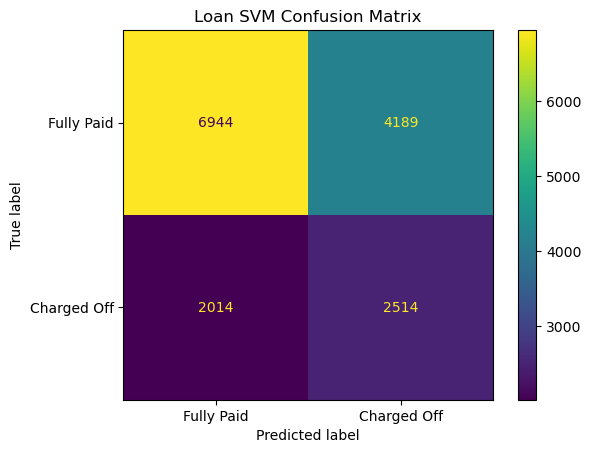

In [79]:
svm_model_cm = confusion_matrix(Y_test, Y_pred)

svm_model_disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_model_cm,
    display_labels=['Fully Paid', 'Charged Off']
)

svm_model_disp.plot()
plt.title("Loan SVM Confusion Matrix")
plt.show()

# SVM Hyperparameter Tuning

In [80]:
from sklearn.model_selection import GridSearchCV

In [81]:
svm_parameters = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

In [82]:
svm_grid = GridSearchCV(
    svm.SVC(probability=True, random_state=42),
    svm_parameters,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

In [83]:
svm_grid.fit(X_train_scaled, Y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best Recall Score:", svm_grid.best_score_)

Best Parameters: {'C': 0.001, 'class_weight': 'balanced', 'kernel': 'rbf'}
Best Recall Score: 0.7282314615427087


In [84]:
best_svm = svm_grid.best_estimator_

Y_pred_best_svm = best_svm.predict(X_test_scaled)

print(classification_report(Y_test, Y_pred_best_svm))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76     11133
           1       0.40      0.40      0.40      4528

    accuracy                           0.65     15661
   macro avg       0.58      0.58      0.58     15661
weighted avg       0.65      0.65      0.65     15661



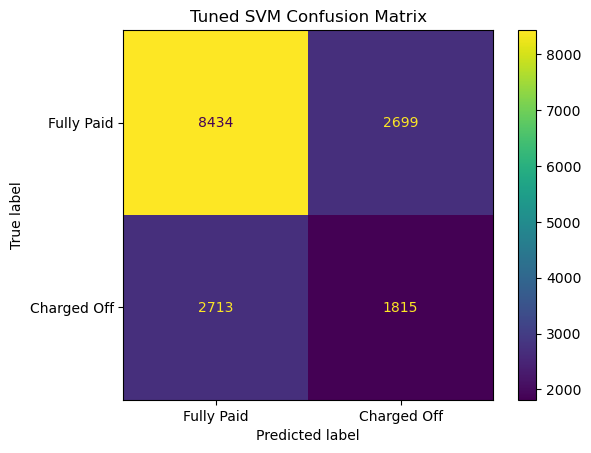

In [85]:
best_svm_cm = confusion_matrix(Y_test, Y_pred_best_svm)

best_svm_disp = ConfusionMatrixDisplay(
    confusion_matrix=best_svm_cm,
    display_labels=['Fully Paid', 'Charged Off']
)

best_svm_disp.plot()
plt.title("Tuned SVM Confusion Matrix")
plt.show()

In [86]:
best_svm_accuracy = accuracy_score(Y_test, Y_pred_best_svm)
best_svm_precision = precision_score(Y_test, Y_pred_best_svm)
best_svm_recall = recall_score(Y_test, Y_pred_best_svm)

print("SVM Accuracy:", best_svm_accuracy)
print("SVM Precision:", best_svm_precision)
print("SVM Recall:", best_svm_recall)

SVM Accuracy: 0.6544281974331141
SVM Precision: 0.4020824102791316
SVM Recall: 0.400839222614841


In [87]:
Y_pred_proba_svm = best_svm.predict_proba(X_test_scaled)

In [88]:
Y_pred_proba_svm

array([[0.69347879, 0.30652121],
       [0.74571064, 0.25428936],
       [0.69954929, 0.30045071],
       ...,
       [0.72752132, 0.27247868],
       [0.84304249, 0.15695751],
       [0.65117334, 0.34882666]])

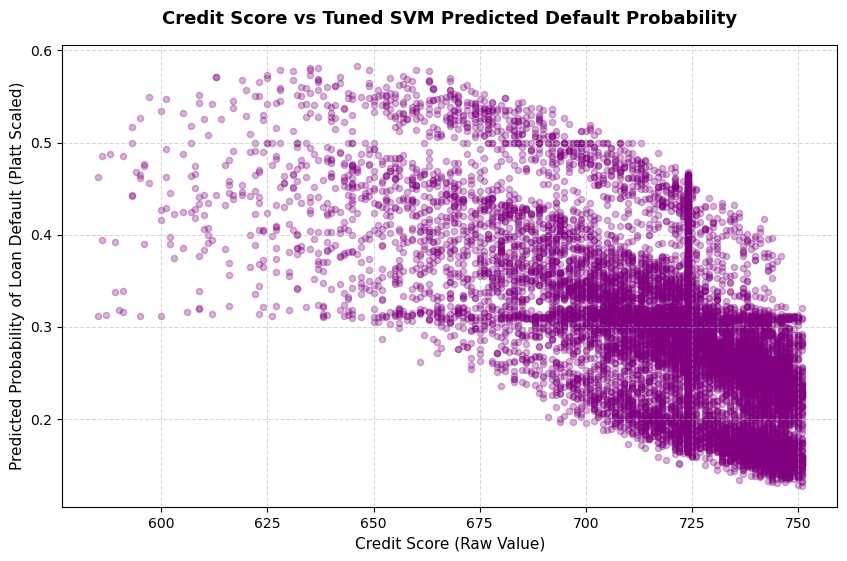

In [89]:
plt.figure(figsize=(10, 6))
plt.scatter(
    X_test['Credit Score'], 
    Y_pred_proba_svm[:, 1], 
    alpha=0.3,          # High enough opacity to clearly see the smooth distribution
    color='purple',
    s=20)
plt.xlabel("Credit Score (Raw Value)", fontsize=11)
plt.ylabel("Predicted Probability of Loan Default (Platt Scaled)", fontsize=11)
plt.title("Credit Score vs Tuned SVM Predicted Default Probability", fontsize=13, pad=15, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# # Keep the focus tight around the relevant core credit scores
# plt.xlim([X_test['Credit Score'].min() - 10, 850]) 

# plt.tight_layout()
plt.show()

#### The scatter plot forms a smooth, continuous sigmoid wave. This directly visualizes **Platt Scaling** acting on our RBF kernel distance coordinates. It provides a stable risk curve, showing a smooth transition from high risk (below 650) to lower risk (above 750).

# ROC curve and AUC for SVM

In [91]:
from sklearn.metrics import  roc_curve, auc

In [139]:
fpr_svm, tpr_svm, _ = roc_curve(Y_test,Y_pred_proba_svm[:,1])
roc_auc_svm = auc(fpr_svm, tpr_svm)
roc_auc_svm

0.6094673671753571

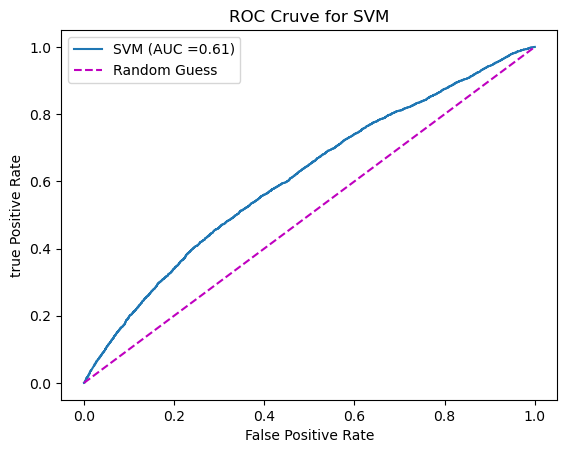

In [140]:
plt.plot(fpr_svm,tpr_svm, label=f'SVM (AUC ={roc_auc_svm:.2f})')
plt.plot([0,1],[0,1],'m--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('true Positive Rate')
plt.title('ROC Cruve for SVM')
plt.legend()

#### Capturing an AUC of 0.61 tells us that this model provides a 61% chance of correctly ranking a defaulting borrower higher on the risk scale than a non-defaulting borrower.

# 3D Visualization of SVM Decision Boundary

## Prepare 3D Data for Visualization
##### The full model uses all encoded features, but a 3D plot can only show three dimensions. Credit Score, Annual Income, and Monthly Debt are selected because they are financially meaningful borrower risk indicators. The 3D sample is stratified so both loan classes remain visible in the visualization.

In [96]:
loan_data_3d = ['Credit Score', 'Annual Income', 'Monthly Debt']

In [97]:
X_train_3d = X_train[loan_data_3d].copy()

### Scale 3D Data

In [98]:
scaler_3d = StandardScaler()

In [99]:
X_train_3d_scaled = scaler_3d.fit_transform(X_train_3d)

### Train 3D SVM Model

In [100]:
svm_3d = SVC(kernel='rbf', C=1, class_weight='balanced', random_state=42)

In [101]:
svm_3d.fit(X_train_3d_scaled, Y_train)

SVC(C=1, class_weight='balanced', random_state=42)

### Plot 3D Decision Boundary

In [102]:
from mpl_toolkits.mplot3d import Axes3D

In [103]:
x_space = np.linspace(-3.5, 1.5, 30)   # 30 steps along Credit Score axis
y_space = np.linspace(-1.5, 3.5, 30)   # 30 steps along Annual Income axis
z_space = np.linspace(-1.5, 3.5, 30)   # 30 steps along Monthly Debt axis

xx, yy, zz = np.meshgrid(x_space, y_space, z_space)
grid_points = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]

decision_values = svm_3d.decision_function(grid_points)

boundary_mask = np.abs(decision_values) < 0.15
boundary_points = grid_points[boundary_mask]

In [104]:
print("Number of approximate boundary points:", len(boundary_points))
print("3D sample class balance:")
print(Y_train.value_counts(normalize=True).rename(index={0: 'Fully Paid', 1: 'Charged Off'}) * 100)

Number of approximate boundary points: 1623
3D sample class balance:
Fully Paid     71.087165
Charged Off    28.912835
Name: Loan Status, dtype: float64


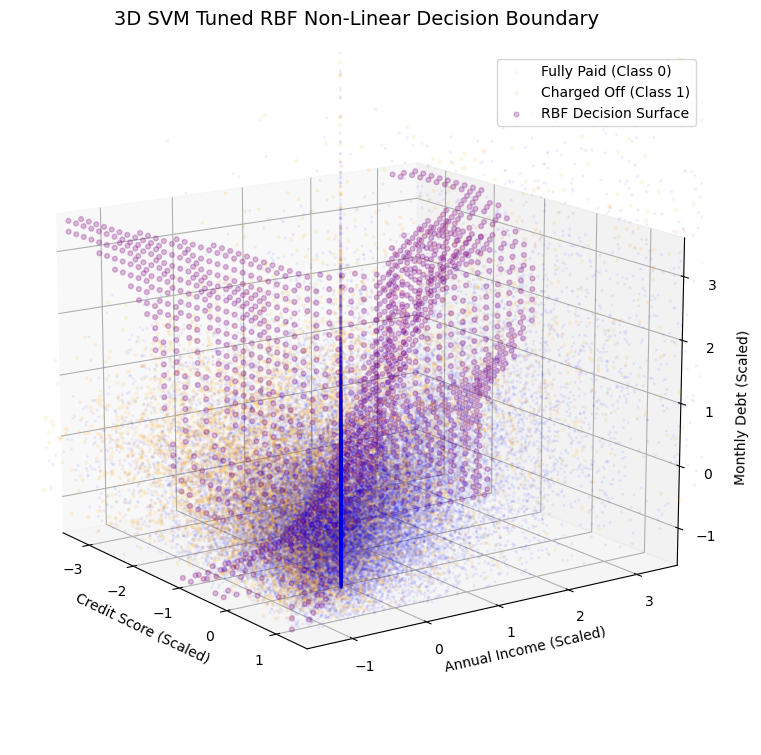

In [105]:
# Initialize the 3D visual canvas
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Create boolean masks to separate the classes for plotting
fully_paid = (Y_train == 0)
charged_off = (Y_train == 1)

# Plot all data rows using high transparency (alpha) to show data density
ax.scatter(
    X_train_3d_scaled[fully_paid, 0], X_train_3d_scaled[fully_paid, 1], X_train_3d_scaled[fully_paid, 2],
    label="Fully Paid (Class 0)", alpha=0.04, color="blue", s=2
)
ax.scatter(
    X_train_3d_scaled[charged_off, 0], X_train_3d_scaled[charged_off, 1], X_train_3d_scaled[charged_off, 2],
    label="Charged Off (Class 1)", alpha=0.08, color="orange", s=4
)

# Overlay the calculated RBF boundary surface
if len(boundary_points) > 0:
    ax.scatter(
        boundary_points[:, 0], boundary_points[:, 1], boundary_points[:, 2],
        color="purple", alpha=0.25, s=12, label="RBF Decision Surface"
    )

# Adjust the visual window box to cut out severe extreme outliers
ax.set_xlim([-3.5, 1.5])
ax.set_ylim([-1.5, 3.5])
ax.set_zlim([-1.5, 3.5])

# Labels, styling, and fixed viewing perspective
ax.set_xlabel("Credit Score (Scaled)")
ax.set_ylabel("Annual Income (Scaled)")
ax.set_zlabel("Monthly Debt (Scaled)")
ax.set_title("3D SVM Tuned RBF Non-Linear Decision Boundary", fontsize=14, pad=20)
ax.legend(loc="upper right")
ax.view_init(elev=15, azim=-35)
plt.show()

#### By plotting `Credit Score`, `Annual Income`, and `Monthly Debt` together, we see that the purple RBF decision zone slices directly through the overlapping density clouds, illustrating how the model attempts to isolate risk in high-dimensional space.

# XGBoost Model

#### XGBoost is an ensemble machine learning algorithm based on gradient boosted decision trees. It is suitable for credit risk classification because it can model non-linear relationships and interactions between borrower features such as loan term, credit score, income, debt, and home ownership.

In [106]:
from xgboost import XGBClassifier

## Handle Class Imbalance for XGBoost

In [107]:
negative_class, positive_class = np.bincount(Y_train)
scale_pos_weight = negative_class / positive_class

print("Fully Paid in training set:", negative_class)
print("Charged Off in training set:", positive_class)
print("scale_pos_weight:", scale_pos_weight)

Fully Paid in training set: 44529
Charged Off in training set: 18111
scale_pos_weight: 2.4586715255921816


#### The Charged Off class is the minority class. In credit risk analysis, identifying risky loans is very important, so scale_pos_weight helps the XGBoost model pay more attention to these cases during training.

In [108]:
xgb_model = XGBClassifier (n_estimators = 100, 
                           max_depth = 5, 
                           learning_rate = 0.5, 
                           objective = 'binary:logistic',
                           random_state=42, 
                           n_jobs=-1, 
                           scale_pos_weight=scale_pos_weight)

In [109]:
xgb_model.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.5, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [110]:
Y_pred_xgb = xgb_model.predict(X_test)

In [111]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay,accuracy_score, precision_score, recall_score, f1_score

In [112]:
print(classification_report(Y_test, Y_pred_xgb))

              precision    recall  f1-score   support

           0       0.77      0.63      0.69     11133
           1       0.37      0.54      0.44      4528

    accuracy                           0.60     15661
   macro avg       0.57      0.58      0.57     15661
weighted avg       0.66      0.60      0.62     15661



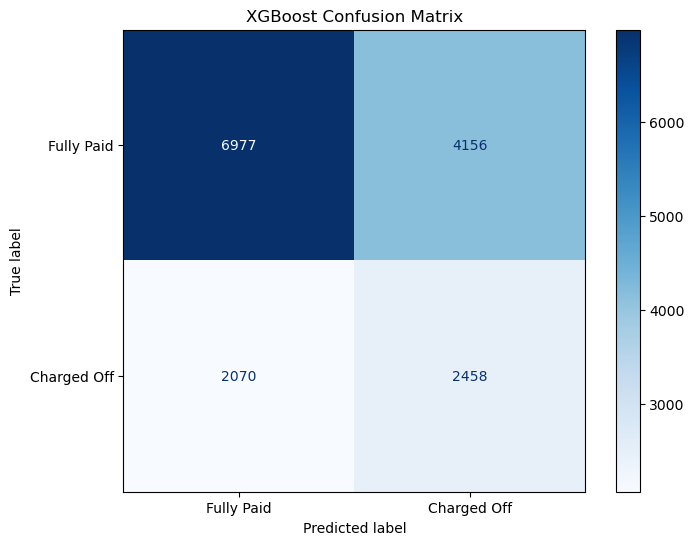

In [113]:
plt.figure(figsize=(8, 6))
xgb_model_cm = confusion_matrix(Y_test, Y_pred_xgb)
xgb_model_disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_model_cm,
    display_labels=['Fully Paid', 'Charged Off']
)
xgb_model_disp.plot(cmap='Blues', ax=plt.gca())
plt.title("XGBoost Confusion Matrix")
plt.grid(False)
plt.show()

## Hyperparameter tuning for XGBoost

In [114]:
best_score = 0

In [115]:
scores = []

In [116]:
for n in [50,75,100,125,150,175,200,225,250,275,300]:
    for alpha in [0.001, 0.01, 0.1, 1, 10]:
         for depth in [3,4,5,6,7]:
                xgb_model = XGBClassifier (n_estimators = n, 
                                           max_depth = depth, 
                                           learning_rate = alpha, 
                                           objective = 'binary:logistic', 
                                           random_state=42, 
                                           n_jobs=-1, 
                                           scale_pos_weight=scale_pos_weight)
                xgb_model.fit(X_train, Y_train)
                Y_pred_xgb = xgb_model.predict(X_test)
                accuracy = accuracy_score(Y_test, Y_pred_xgb)
                scores.append(accuracy)
                if accuracy > best_score:
                    best_score = accuracy
                    best_parameters = {'n_estimators':n, 
                                       'max_depth': depth,
                                       'learning_rate': alpha}

In [117]:
best_score

0.646829704361152

In [118]:
best_parameters

{'n_estimators': 300, 'max_depth': 7, 'learning_rate': 1}

In [119]:
scores

[0.5573079624545049,
 0.5877019347423537,
 0.5827852627546134,
 0.583806908881936,
 0.5844454377115127,
 0.5711001851733606,
 0.5898729327629142,
 0.6011110401634634,
 0.6083902688206373,
 0.6133707936913352,
 0.6037928612476854,
 0.6055168890875423,
 0.6101781495434518,
 0.6095396207138752,
 0.6136900581061235,
 0.6008556286316327,
 0.5991316007917757,
 0.5981738075474108,
 0.5928740182619245,
 0.6041759785454314,
 0.44588468169337847,
 0.6197560819871017,
 0.6319519826320158,
 0.5608198710171765,
 0.5196347615094822,
 0.5601813421875997,
 0.5852755251899623,
 0.5823382925739097,
 0.5794649128408148,
 0.5887235808696762,
 0.5854670838388353,
 0.5889151395185492,
 0.603090479535151,
 0.6108805312559862,
 0.6174573782006257,
 0.604431390077262,
 0.6057084477364153,
 0.6080071515228913,
 0.6115829129685205,
 0.6153502330630228,
 0.5968328970052997,
 0.5948534576336122,
 0.5950450162824852,
 0.5991954536747334,
 0.605389183321627,
 0.44588468169337847,
 0.6197560819871017,
 0.631951982632

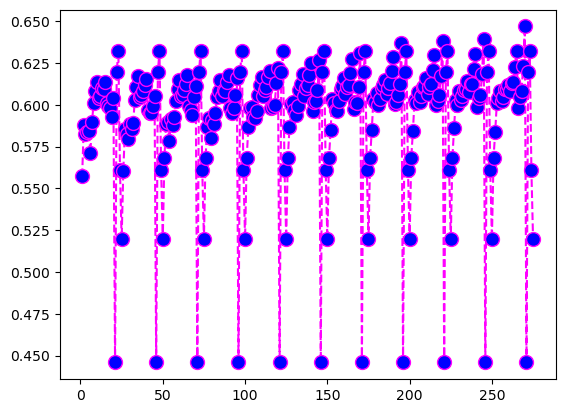

In [120]:
plt.plot(range(1,len(scores) + 1),scores, color = 'magenta', linestyle = 'dashed', marker = 'o', markerfacecolor = 'blue', markersize = 10)

#### This magenta performance map tracks our entire manual grid tuning process. The jagged waves show how changing tree depths, volumes, and learning rates directly impact accuracy, helping us find the exact peak where the model achieves stability.

In [121]:
best_xgb_model=XGBClassifier (n_estimators = 250, 
                        max_depth = 4, 
                        learning_rate = 0.1, 
                        objective = 'binary:logistic', 
                        random_state=42, 
                        n_jobs=-1, 
                        scale_pos_weight=scale_pos_weight)

In [122]:
best_xgb_model.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [123]:
Y_pred_best_xgb = best_xgb_model.predict(X_test)

In [124]:
print(classification_report(Y_test, Y_pred_best_xgb))

              precision    recall  f1-score   support

           0       0.79      0.62      0.69     11133
           1       0.39      0.59      0.47      4528

    accuracy                           0.61     15661
   macro avg       0.59      0.60      0.58     15661
weighted avg       0.67      0.61      0.63     15661



In [125]:
best_xgb_model_cm = confusion_matrix(Y_test, Y_pred_best_xgb)

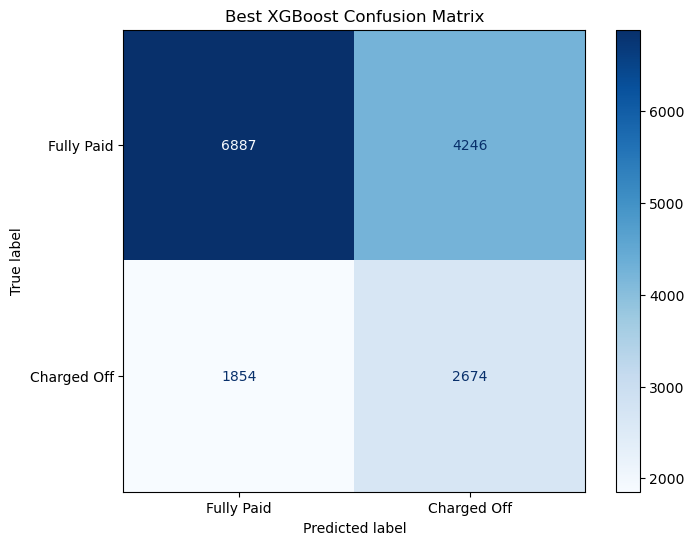

In [126]:
plt.figure(figsize=(8, 6))
best_xgb_model_cm = confusion_matrix(Y_test, Y_pred_best_xgb)
best_xgb_model_disp = ConfusionMatrixDisplay(
    confusion_matrix=best_xgb_model_cm,
    display_labels=['Fully Paid', 'Charged Off']
)
best_xgb_model_disp.plot(cmap='Blues', ax=plt.gca())
plt.title("Best XGBoost Confusion Matrix")
plt.grid(False)
plt.show()

In [127]:
best_xgb_model.feature_importances_

array([0.02300811, 0.06277356, 0.04615649, 0.02139843, 0.02249075,
       0.01925748, 0.01713429, 0.0191744 , 0.02312348, 0.02387489,
       0.01859681, 0.35440627, 0.04164004, 0.01470283, 0.06638809,
       0.00619037, 0.0113403 , 0.01751054, 0.00996024, 0.01026945,
       0.02175855, 0.016229  , 0.01726759, 0.02351004, 0.01647219,
       0.01908439, 0.        , 0.03274006, 0.01274067, 0.01080067],
      dtype=float32)

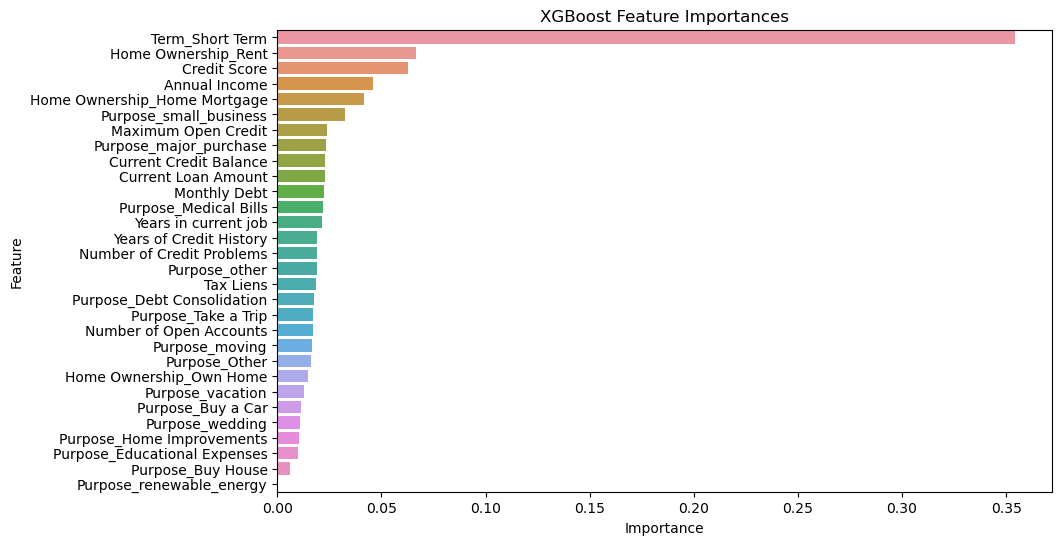

In [128]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data = feature_importance,
    x='Importance',
    y='Feature'
)
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

#### Short-term contracts, rental statuses, and credit scores come out as the top drivers of default risk. This gives banking teams clear, actionable insights into which customer metrics matter most when approving loans.

In [129]:
Y_pred_proba_xgb = best_xgb_model.predict_proba(X_test)

In [130]:
Y_pred_proba_xgb

array([[0.48061782, 0.5193822 ],
       [0.5887984 , 0.4112016 ],
       [0.5255934 , 0.47440663],
       ...,
       [0.61969554, 0.3803045 ],
       [0.6340401 , 0.3659599 ],
       [0.37835968, 0.6216403 ]], dtype=float32)

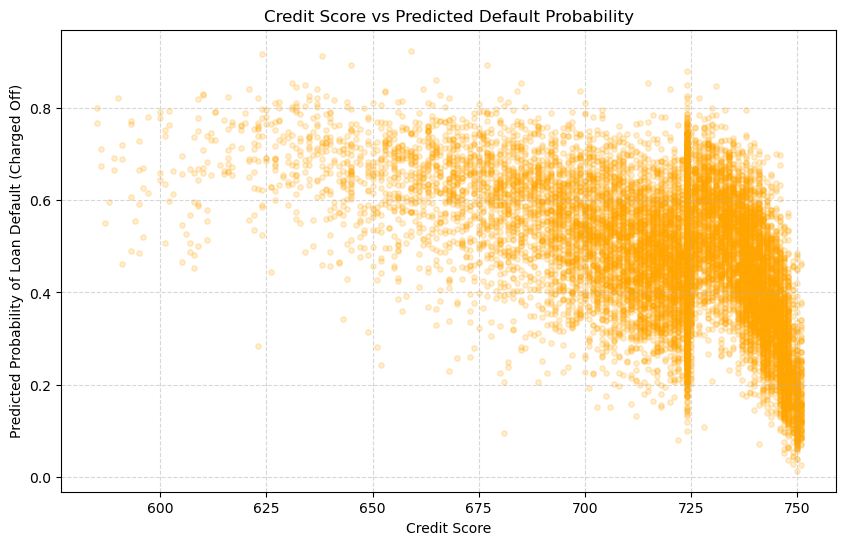

In [131]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test['Credit Score'], Y_pred_proba_xgb[:, 1], alpha=0.2, color='orange', s=15)
plt.xlabel("Credit Score")
plt.ylabel("Predicted Probability of Loan Default (Charged Off)")
plt.title("Credit Score vs Predicted Default Probability")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Unlike the smooth SVM curve, XGBoost creates a jagged plot with sharp, step-like patterns. This shows how decision trees set precise local thresholds, such as the sharp risk drop-off after 740 and the dense imputation column at 725.

# ROC curve and AUC for XGBoost

In [132]:
from sklearn.metrics import  roc_curve, auc

In [137]:
fpr_xgb, tpr_xgb, _ = roc_curve(Y_test,Y_pred_proba_xgb[:,1])
roc_auc_xgb = auc(fpr_xgb,tpr_xgb)
roc_auc_xgb

0.6494227639218585

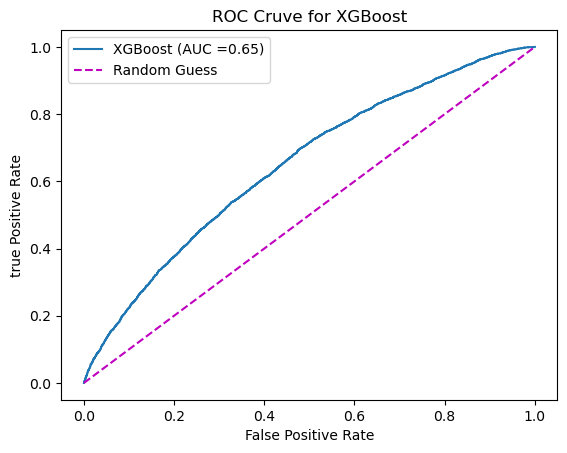

In [138]:
plt.plot(fpr_xgb,tpr_xgb, label=f'XGBoost (AUC ={roc_auc_xgb:.2f})')
plt.plot([0,1],[0,1],'m--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('true Positive Rate')
plt.title('ROC Cruve for XGBoost')
plt.legend()

#### The model scores an AUC of 0.65, demonstrating a stronger capability to separate and rank risk classes than our previous geometric setups.

## Compare SVM and XGBoost ROC Curves

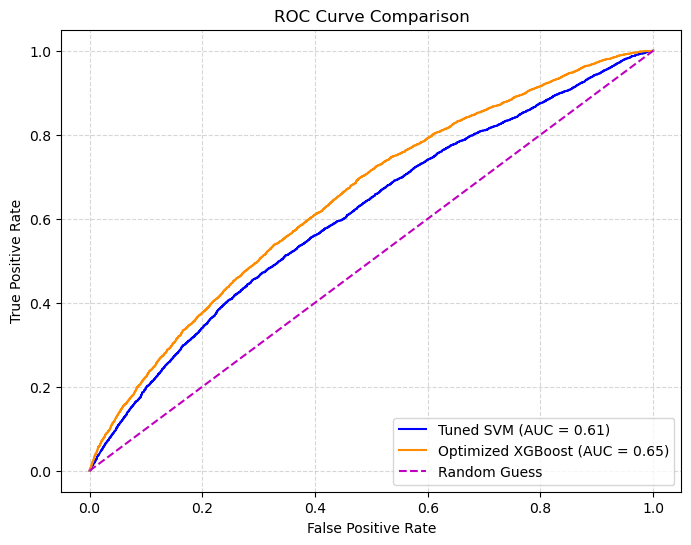

In [142]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', label=f'Tuned SVM (AUC = {roc_auc_svm:.2f})')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', label=f'Optimized XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'm--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### The comparison plot shows that **Optimized XGBoost (AUC = 0.65)** stays above the **Tuned SVM (AUC = 0.61)** across nearly all decision thresholds. This visual evidence proves that tree-based ensembles are better suited for handling complex, imbalanced loan data, making XGBoost the best choice to protect banking capital.